<a href="https://colab.research.google.com/github/Zeeshan4511/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zeeshan4511/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Can a machine learning model use demographic, dietary, and lifestyle features to classify whether a participant is in the low-risk or high-risk colorectal cancer risk category in the available dataset?

### Decision Supported

The project is designed as a research and decision-support prototype. The model can help rank records for human review based on their measured predicted risk.

The goal is not to diagnose colorectal cancer. Instead, the project explores whether the available participant features contain useful directional patterns for binary risk classification.


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/crc_dataset.csv")

print("Dataset rows:", len(df))
print("Dataset columns:", len(df.columns))
print("\nTarget distribution:")
print(df["CRC_Risk"].value_counts())

Dataset rows: 1000
Dataset columns: 15

Target distribution:
CRC_Risk
0    845
1    155
Name: count, dtype: int64


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The project uses the colorectal cancer risk dataset provided for the FlyRank ML Internship.

The dataset contains 1,000 participant records and includes demographic, lifestyle, family-history, pre-existing-condition, and dietary features.

The main fields used in the analysis include:

* Age
* Gender
* BMI
* Lifestyle
* Ethnicity
* Family History of CRC
* Pre-existing Conditions
* Carbohydrates
* Proteins
* Fats
* Vitamin A
* Vitamin C
* Iron

`Participant_ID` was excluded from model training because it identifies the participant rather than representing a predictive characteristic.

`CRC_Risk` was used as the target variable, where 0 represents Low Risk and 1 represents High Risk.

Missing values in `Pre-existing Conditions` were treated as `None`.

No private client information, private search queries, or personally identifying information was intentionally used in the analysis.

The available dataset does not provide a meaningful date window or separate client identifier, so a true time-aware or client-level validation could not be performed.


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["CRC_Risk"].value_counts())

Rows: 1000
Columns: 15

Missing values:
Participant_ID               0
Age                          0
Gender                       0
BMI                          0
Lifestyle                    0
Ethnicity                    0
Family_History_CRC           0
Pre-existing Conditions    238
Carbohydrates (g)            0
Proteins (g)                 0
Fats (g)                     0
Vitamin A (IU)               0
Vitamin C (mg)               0
Iron (mg)                    0
CRC_Risk                     0
dtype: int64

Target distribution:
CRC_Risk
0    845
1    155
Name: count, dtype: int64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Model

Random Forest was selected as the primary model because it can capture non-linear relationships and provides feature-importance information that can help with interpretation.

Logistic Regression was used as the baseline because it is a simple and commonly used classification method.

### Features

The model uses demographic, lifestyle, family-history, pre-existing-condition, and dietary variables. `Participant_ID` and the target variable `CRC_Risk` were excluded from the feature set.

Categorical variables were encoded into numerical values before modelling. Missing pre-existing-condition values were represented as `None`.

### Label Definition

The target variable is `CRC_Risk`, where 0 represents Low Risk and 1 represents High Risk. The model learns to reproduce the categories present in the supplied dataset.

### Validation Design

The original Week-5 evaluation used an 80/20 stratified random train-test split with `random_state=42`.

In Week 6, I performed an additional grouped validation check using `Participant_ID`. Because each participant appears as an individual record and there is no separate client identifier or repeated participant history, this does not represent a true client-level validation.

### Leakage Checks

I checked the final feature set for direct target leakage and excluded both `CRC_Risk` and `Participant_ID` from the predictors.

I also identified that categorical encoding should ideally be fitted only on the training data in a stricter production-style pipeline. Therefore, the current results should be interpreted as research results from this analysis rather than production-ready model performance.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df["Pre-existing Conditions"] = df["Pre-existing Conditions"].fillna("None")

model_df = df.copy()

for col in model_df.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    model_df[col] = encoder.fit_transform(model_df[col])

X = model_df.drop(["Participant_ID", "CRC_Risk"], axis=1)
y = model_df["CRC_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of features:", X.shape[1])

Training samples: 800
Testing samples: 200
Number of features: 13


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Random Forest model was compared with Logistic Regression using the same dataset, train-test split, and evaluation metrics.

On the original random split, Random Forest achieved an observed accuracy of 90.5%, precision of 92.9%, recall of 41.9%, and F1-score of 57.8%.

Logistic Regression achieved an observed accuracy of 87.0%, precision of 69.2%, recall of 29.0%, and F1-score of 40.9% in the final Week-6 rerun.

Random Forest therefore showed higher measured performance than the Logistic Regression baseline on this tested split.

However, the recall for the high-risk class was 41.9%. This means that the model did not identify every high-risk participant in the test set. Therefore, accuracy alone should not be used to describe the model as highly reliable.

These results are observed measurements on this dataset and should not be interpreted as evidence of clinical accuracy or real-world generalisation.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

baseline = LogisticRegression(max_iter=2000)
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.870,0.692308,0.290323,0.409091
1,Random Forest,0.905,0.928571,0.419355,0.577778


## 5. Limitations

*What this work cannot claim.*

This project has several important limitations.

First, the dataset represents a limited set of participant records and may not represent other populations or real clinical settings.

Second, the validation design is based mainly on a random participant-level split. The dataset does not contain a true client identifier, repeated participant observations, or a suitable date field for strong client-level or time-aware validation.

Third, the model's recall for the high-risk class was 41.9% on the tested random split. Therefore, the model can miss some high-risk records.

Fourth, the current preprocessing approach encodes categorical features before splitting the data. A stricter modelling pipeline would fit preprocessing only on the training data.

Finally, model feature importance shows associations used by the model, not causal relationships. A feature being important to the model does not prove that it causes colorectal cancer risk.

For these reasons, the model should be described as a research and decision-support prototype. It should not be presented as a clinically validated diagnostic system.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The action playbook converts model predictions into a ranked review queue.

### 1. High Priority Review

Records with higher measured predicted risk should be reviewed first by a human reviewer.

**Reason codes may include:**

* Age directional signal
* BMI directional signal
* Family history signal
* Lifestyle signal

These reason codes describe patterns observed by the model and are not causal explanations.

### 2. Standard Review

Records with moderate predicted risk can be placed in the normal review queue. A reviewer should consider the complete available information before taking any action.

### 3. No Immediate Model-Based Action

Lower predicted-risk records do not automatically require an intervention based on this model.

### Human Review

A person should check the available participant information, data quality, unusual values, and model reason codes before making a decision.

### No-Go Cases

The model should not be used to:

* Automatically diagnose colorectal cancer.
* Automatically start or stop treatment.
* Automatically refer or reject a participant.
* Send an automated medical diagnosis.
* Replace professional judgement.

The recommendations are intended for research and decision-support use only.


In [ ]:
rf_probability = rf.predict_proba(X_test)[:, 1]

recommendations = df.iloc[X_test.index].copy()

recommendations["Predicted_Risk_Probability"] = rf_probability

recommendations["Priority"] = pd.cut(
    recommendations["Predicted_Risk_Probability"],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=[
        "No Immediate Action",
        "Standard Review",
        "High Priority Review"
    ]
)

recommendations = recommendations.sort_values(
    "Predicted_Risk_Probability",
    ascending=False
)

recommendations[[
    "Participant_ID",
    "Predicted_Risk_Probability",
    "Priority"
]].head(10)

,Participant_ID,Predicted_Risk_Probability,Priority
976,1977,0.750,High Priority Review
751,1752,0.730,High Priority Review
208,1209,0.725,High Priority Review
126,1127,0.710,High Priority Review
676,1677,0.695,High Priority Review
332,1333,0.695,High Priority Review
54,1055,0.645,Standard Review
413,1414,0.635,Standard Review
575,1576,0.605,Standard Review
412,1413,0.570,Standard Review


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The paper uses reproducible tables and figures generated from the notebook.

The main artifacts are:

1. Model comparison table showing Random Forest versus Logistic Regression.
2. Feature importance chart showing the variables used most strongly by the Random Forest model.
3. Confusion matrix showing correct and incorrect classifications.
4. Ranked action queue generated from the model's predicted risk probabilities.

These artifacts are generated from the analysis rather than manually entered so that the reported results can be traced back to the notebook.


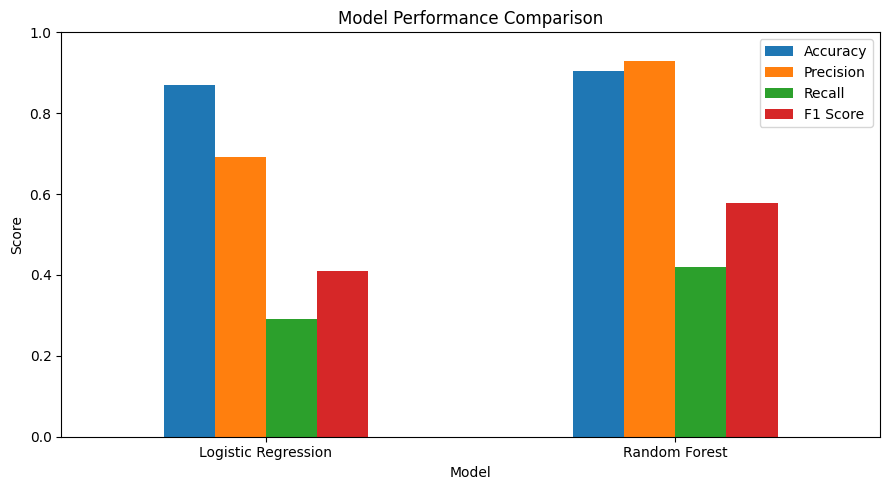

In [ ]:
import matplotlib.pyplot as plt

results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

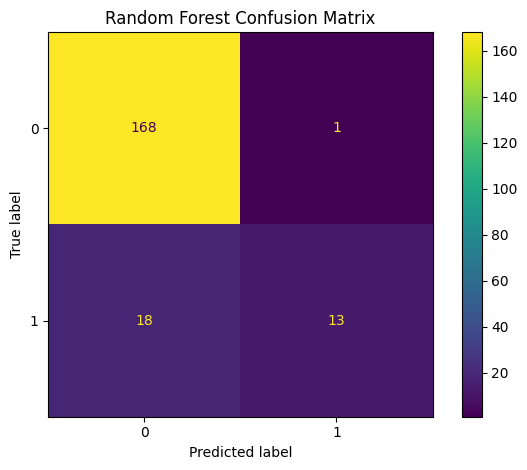

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

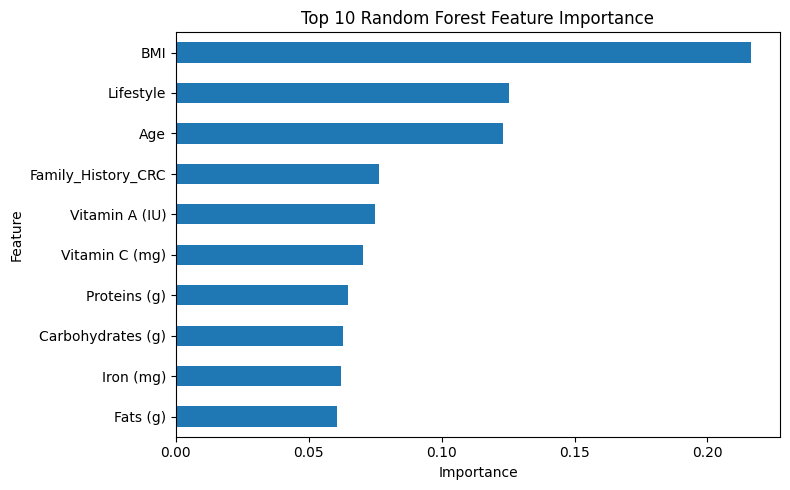

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

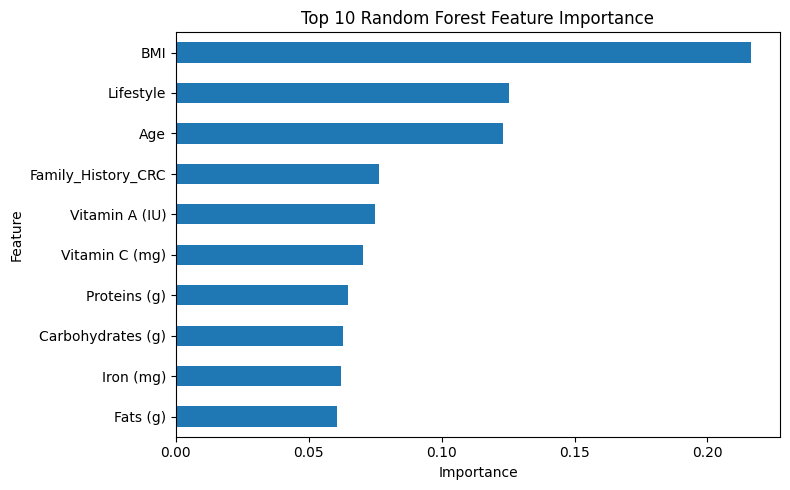

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

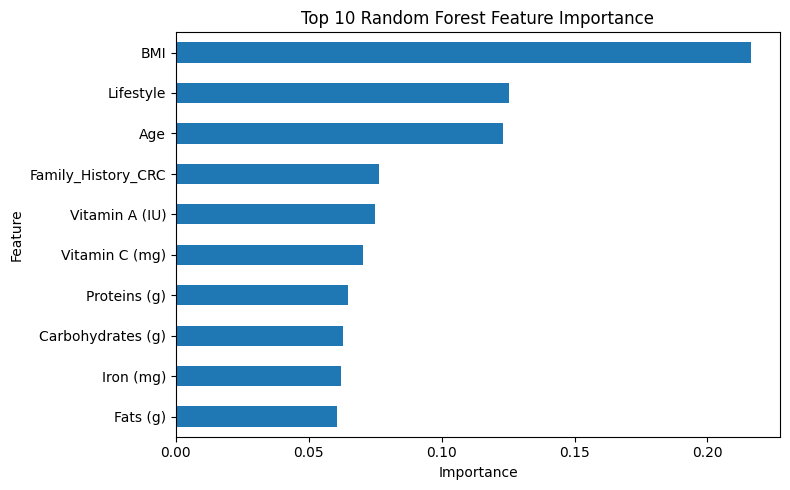

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [✅] Every section above is filled — markdown thinking AND the code that backs it
- [✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅] No client names, URLs, or private queries anywhere
- [✅] My claims use careful words: observed, measured, directional, decision-support
- [✅] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.